# Advanced modeling tools in Bioscrape

This notebook shows how to edit Bioscrape models after they have been created (either loaded from SBML or created directly within Bioscrape). Specifically, the notebook demonstrates the following tools in Bioscrape:

* Additive rules
* Assignment rules 
* Creating events during simulation using `Heaviside`


In [1]:
import os
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bioscrape.types import Model
from bioscrape.simulator import py_simulate_model

# %matplotlib inline


## Construct the model

Consider a model that has a conversion reaction, a reporter reaction controlled by a parameter named `signal`, and a few extra species that will be set by rules. 

Note that in Bioscrape the rule targets must already be species or parameters in the model before `create_rule` is called.


### Use Bioscrape API to create the model

In [2]:
species = ["A", "B", "Total", "Programmed", "Reporter"]
params = [
    ("k_convert", 0.08),
    ("signal", 0.05),
    ("signal_low", 0.05),
    ("signal_high", 1.20),
    ("gamma", 0.05),
    ("T_signal", 25.0),
    ("X0", 2.0),
    ("X1", 10.0),
]
reactions = [
    (["A"], ["B"], "massaction", {"k": "k_convert"}),
    ([], ["Reporter"], "massaction", {"k": "signal"}),
    (["Reporter"], [], "massaction", {"k": "gamma"}),
]
x0 = {"A": 1.0, "B": 0.0, "Total": 0.0, 
      "Programmed": 2.0, "Reporter": 0.0}

M = Model(species=species, parameters=params,
          reactions=reactions,
          initial_condition_dict=x0)

# Later, we will import the SBML for it, so write it as an SBML:
M.write_sbml_model("models/bioscrape_rules_example.xml")

True

## Rules in Bioscrape

In [3]:
# Additive rule to track a conserved total as an output species.
M.create_rule("additive", {"equation": "Total = A + B"})

# Assignment rule on a species to set a value from parameters in the middle of the simulation.
M.create_rule(
    "assignment",
    {"equation": "Programmed = X0 + (X1-X0)*Heaviside(t-T_signal)"},
)

# Assignment rule on a parameter to switch a kinetic parameter in the middle of the simulation.
M.create_rule(
    "assignment",
    {"equation": "signal = signal_low + (signal_high-signal_low)*Heaviside(t-T_signal)"},
)


### Simulate and verify

max |Total - 1|: 8.881784197001252e-16
Programmed just before switch: 2.0
Programmed at switch: 10.0
Reporter slope before switch: 0.02386512194993028
Reporter slope after switch: 0.43280707452141876


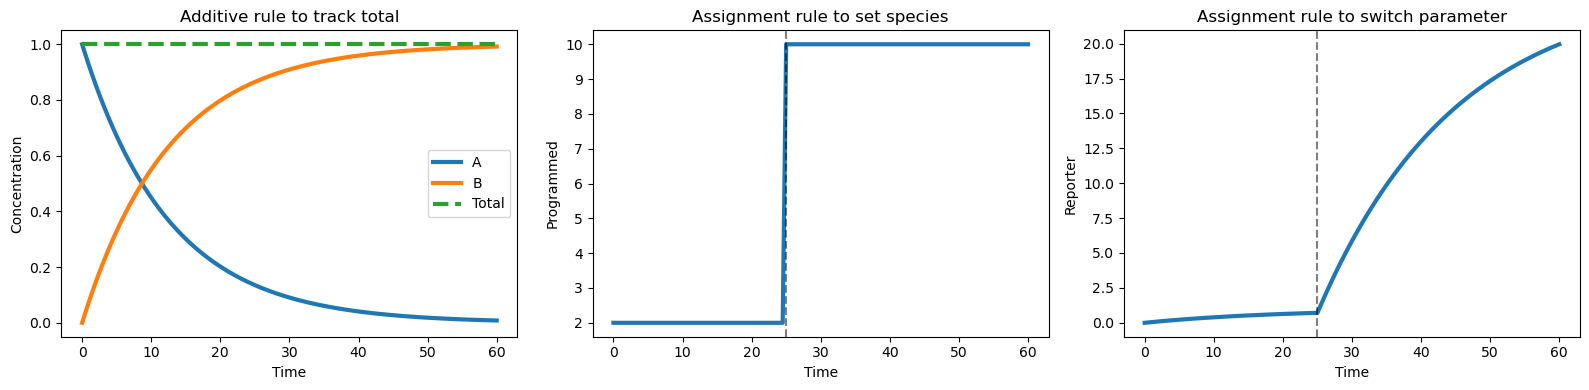

In [4]:
timepoints = np.linspace(0, 60, 121)
sim_result = py_simulate_model(timepoints, Model=M,
                               stochastic=False, return_dataframe=False)
results = pd.DataFrame(sim_result.py_get_result(),
                       columns=M.get_species_list())
results.loc[:, "time"] = timepoints

total_error = np.max(np.abs(results["Total"] - 1.0))
before_switch = results.loc[results["time"] < 25.0, "Programmed"].iloc[-1]
at_switch = results.loc[results["time"] == 25.0, "Programmed"].iloc[0]
reporter_slope_before = (results.loc[40, "Reporter"] - results.loc[20, "Reporter"]) / (timepoints[40] - timepoints[20])
reporter_slope_after = (results.loc[100, "Reporter"] - results.loc[80, "Reporter"]) / (timepoints[100] - timepoints[80])

print("max |Total - 1|:", total_error)
print("Programmed just before switch:", before_switch)
print("Programmed at switch:", at_switch)
print("Reporter slope before switch:", reporter_slope_before)
print("Reporter slope after switch:", reporter_slope_after)

assert total_error < 1e-8
assert before_switch == 2.0
assert at_switch == 10.0
assert reporter_slope_after > reporter_slope_before

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].plot(results["time"], results["A"], lw=3, label="A")
axs[0].plot(results["time"], results["B"], lw=3, label="B")
axs[0].plot(results["time"], results["Total"], "--", lw=3, label="Total")
axs[0].set_title("Additive rule to track total")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Concentration")
axs[0].legend()

axs[1].plot(results["time"], results["Programmed"], lw=3)
axs[1].axvline(25, color="k", linestyle="--", alpha=0.5)
axs[1].set_title("Assignment rule to set species")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Programmed")

axs[2].plot(results["time"], results["Reporter"], lw=3)
axs[2].axvline(25, color="k", linestyle="--", alpha=0.5)
axs[2].set_title("Assignment rule to switch parameter")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Reporter")
plt.tight_layout()


## Import an SBML model and then edit it

Instead of creating a model using Bioscrape API, it is more likely that you have your own SBML file from another modeling tool (like BioCRNplyer). You can import the SBML into Bioscrape and then edit it using the same tools as above. We do this next.

### Load the SBML model

In [5]:
sbml_model = Model(sbml_filename="models/bioscrape_rules_example.xml")
print("Species imported from SBML:")
print(sbml_model.get_species_list())
print("\nParameters imported from SBML:")
print(sbml_model.get_parameter_dictionary())


Species imported from SBML:
['A', 'B', 'Programmed', 'Reporter', 'Total']

Parameters imported from SBML:
{'T_signal': 25.0, 'X0': 2.0, 'X1': 10.0, 'gamma': 0.05, 'k_convert': 0.08, 'signal': 0.05, 'signal_high': 1.2, 'signal_low': 0.05}


### Add rules to the model loaded using SBML

In [6]:
# Additive rule to track a conserved total as an output species.
sbml_model.create_rule("additive", {"equation": "Total = A + B"})

# Assignment rule on a species to set a value from parameters in the middle of the simulation.
sbml_model.create_rule(
    "assignment",
    {"equation": "Programmed = X0 + (X1-X0)*Heaviside(t-T_signal)"},
)

# Assignment rule on a parameter to switch a kinetic parameter in the middle of the simulation.
sbml_model.create_rule(
    "assignment",
    {"equation": "signal = signal_low + (signal_high-signal_low)*Heaviside(t-T_signal)"},
)

In [7]:
print("Rules added after SBML import:")
for rule in sbml_model.get_rules():
    print(rule)

Rules added after SBML import:
('additive', {'equation': 'Total = A + B'}, 'repeated')
('assignment', {'equation': 'Programmed = X0 + (X1-X0)*Heaviside(t-T_signal)'}, 'repeated')
('assignment', {'equation': 'signal = signal_low + (signal_high-signal_low)*Heaviside(t-T_signal)'}, 'repeated')


### Simulate and verify

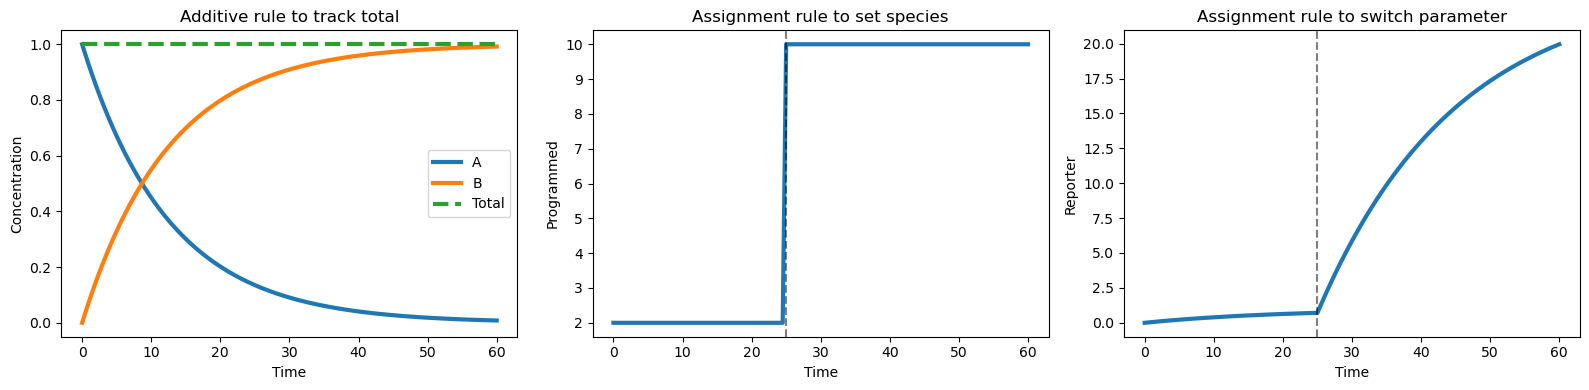

In [8]:
timepoints = np.linspace(0, 60, 121)
sim_result = py_simulate_model(timepoints, Model=sbml_model, stochastic=False, return_dataframe=False)
results = pd.DataFrame(sim_result.py_get_result(), columns=sbml_model.get_species_list())
results.loc[:, "time"] = timepoints

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].plot(results["time"], results["A"], lw=3, label="A")
axs[0].plot(results["time"], results["B"], lw=3, label="B")
axs[0].plot(results["time"], results["Total"], "--", lw=3, label="Total")
axs[0].set_title("Additive rule to track total")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Concentration")
axs[0].legend()

axs[1].plot(results["time"], results["Programmed"], lw=3)
axs[1].axvline(25, color="k", linestyle="--", alpha=0.5)
axs[1].set_title("Assignment rule to set species")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Programmed")

axs[2].plot(results["time"], results["Reporter"], lw=3)
axs[2].axvline(25, color="k", linestyle="--", alpha=0.5)
axs[2].set_title("Assignment rule to switch parameter")
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Reporter")
plt.tight_layout()


The species `Programmed` behaves like an initial condition whose value is stored in parameters: it is set to `X0` before `T_signal` and to `X1` after `T_signal`. The parameter `signal` is changed by the same idea, and the reporter trajectory verifies that the kinetic rate changes after the switch.


## Sensitivity analysis with rules

Sensitivity analysis can be run on a model whose parameter is changed by an assignment rule during simulation. Here the SBML model written earlier is loaded again, then the `signal` parameter is switched from `signal_low` to `signal_high`. The sensitivities below show how the reporter trajectory responds to the low signal level, the high signal level, and reporter degradation.


In [16]:
from bioscrape.analysis import py_sensitivity_analysis

sensitivity_model = Model(sbml_filename="models/bioscrape_rules_example.xml")

# Add a rule as described above:
sensitivity_model.create_rule(
    "assignment",
    {"equation": "signal = signal_low + (signal_high-signal_low)*Heaviside(t-T_signal)"},
)

timepoints_sensitivity = np.linspace(0, 60, 121)
# name the params for plotting and data display
sensitivity_parameters = ["signal_low", "signal_high", "gamma"]

# Use bioscrape's `py_sensitivity_analysis` to compute sensitivity coefficients
SSM_with_rules = py_sensitivity_analysis(
    sensitivity_model,
    timepoints_sensitivity,
    normalize=True,
    params=sensitivity_parameters,
    method="central_difference",
)


C:\Users\apand\AppData\Roaming\Python\Python312\site-packages\bioscrape\analysis.py:486: RuntimeWarning: invalid value encountered in divide
  SSM_normalized[:,j,i] = np.divide(SSM[:,j,i]*params_values[j], solutions[:,i])


### Sensitivity coefficients for each parameter with time for the reporter species

In [17]:
reporter_index = sensitivity_model.get_species_list().index("Reporter")
reporter_sensitivities = pd.DataFrame(
    SSM_with_rules[:, :, reporter_index],
    columns=sensitivity_parameters,
)
reporter_sensitivities.loc[:, "time"] = timepoints_sensitivity
reporter_sensitivities.head()


,signal_low,signal_high,gamma,time
0,NaN,NaN,NaN,0.0
1,1.0,0.0,0.000000,0.5
2,1.0,0.0,-0.012499,1.0
3,1.0,0.0,-0.024893,1.5
4,1.0,0.0,-0.037182,2.0


### Plot a heatmap of sensitivities with time (to see the effect of the rule)

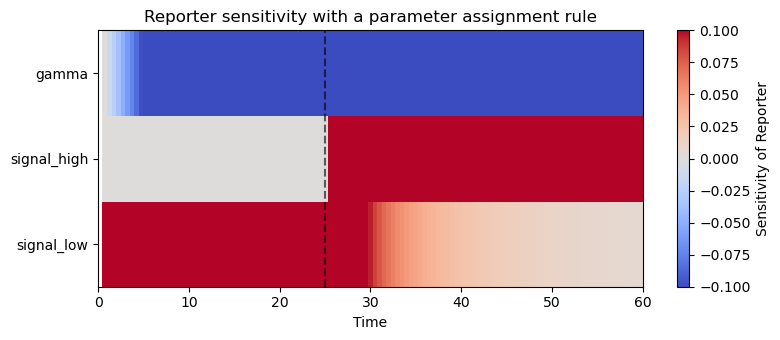

In [18]:
heatmap_values = reporter_sensitivities[sensitivity_parameters].to_numpy().T
heatmap_scale = np.max(np.abs(heatmap_values))

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(
    heatmap_values,
    aspect="auto",
    interpolation="nearest",
    origin="lower",
    extent=[
        timepoints_sensitivity[0],
        timepoints_sensitivity[-1],
        -0.5,
        len(sensitivity_parameters) - 0.5,
    ],
    cmap="coolwarm",
    vmin=-heatmap_scale,
    vmax=heatmap_scale,
)
ax.axvline(
    sensitivity_model.get_parameter_dictionary()["T_signal"],
    color="k",
    linestyle="--",
    alpha=0.6,
)
ax.set_yticks(np.arange(len(sensitivity_parameters)))
ax.set_yticklabels(sensitivity_parameters)
ax.set_xlabel("Time")
ax.set_title("Reporter sensitivity with a parameter assignment rule")
fig.colorbar(im, ax=ax, label="Sensitivity of Reporter")
plt.tight_layout()


In [19]:
# end